# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Hayter Cortés Muñoz
- Nombre de alumno 2: Robert Collins Dättwyler

### **Link de repositorio de GitHub:** [Repositorio Laboratorios](https://github.com/HayterCortes/lab-programacion-cientifica-para-ciencia-de-datos)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1.  **Diferencia entre datos de entrenamiento y validación:**
    *   **Datos de Entrenamiento:** Son el conjunto de datos que se utiliza para "enseñar" al modelo de machine learning. Durante el entrenamiento, el modelo ajusta sus parámetros internos para aprender los patrones y relaciones en los datos. Es la fase donde el modelo aprende a mapear las características de entrada a las etiquetas de salida.
    *   **Datos de Validación:** Son un conjunto de datos separado e independiente que se utiliza para evaluar el rendimiento del modelo durante la fase de entrenamiento. Se usan para ajustar hiperparámetros (parámetros que no son aprendidos por el modelo directamente, como la tasa de aprendizaje o el número de árboles en un bosque aleatorio) y para tener una idea de qué tan bien se generalizará el modelo a datos no vistos. Los datos de validación ayudan a prevenir el sobreajuste (overfitting), donde el modelo se desempeña muy bien en los datos de entrenamiento pero mal en datos nuevos.

2.  **Principal desafío al trabajar problemas de clasificación con data no supervisada:**
    El principal desafío es la **falta de etiquetas (labels)**. En la clasificación supervisada, se tienen ejemplos donde ya se conoce la clase correcta a la que pertenece cada instancia. En cambio, en la clasificación no supervisada, el objetivo es encontrar estructuras o agrupaciones (clusters) en los datos sin tener conocimiento previo de las clases. El desafío radica en cómo interpretar y asignar significado a estos grupos descubiertos, y cómo evaluar si las agrupaciones encontradas corresponden a las clases que se esperaría identificar en un problema de clasificación. No hay una métrica directa de "precisión" o "recall" en el sentido supervisado, ya que no hay una verdad fundamental con la que comparar.

3.  **Matriz de Confusión:**
    En mis palabras, la matriz de confusión es como una tabla resumen que te muestra qué tan bien (o mal) se desempeñó tu modelo de clasificación en la tarea de predecir las clases. Esencialmente, compara las predicciones de tu modelo con los valores reales (las etiquetas verdaderas) para cada una de las clases. Te muestra cuántas veces el modelo predijo correctamente una clase (verdaderos positivos y verdaderos negativos) y cuántas veces se equivocó (falsos positivos y falsos negativos), detallando en qué clase se equivocó. Se utiliza para obtener una visión detallada de los tipos de errores que está cometiendo el modelo y para calcular métricas de rendimiento más allá de la simple precisión general.

4.  **Fórmulas e interpretación de métricas:**

* **Accuracy (Exactitud):**
  Fórmula: $\text{Accuracy} = \frac{\text{Número de Predicciones Correctas}}{\text{Número Total de Predicciones}}$
  Interpretación: Representa la proporción de predicciones totales que fueron correctas. Es una métrica general que indica qué tan a menudo el modelo acierta en sus predicciones, tanto para la clase positiva como para la negativa. Es útil cuando las clases están balanceadas.

* **Precision (Precisión):**
  Fórmula: $\text{Precision} = \frac{\text{Verdaderos Positivos}}{\text{Verdaderos Positivos} + \text{Falsos Positivos}}$
  Interpretación: Mide la proporción de las instancias que el modelo predijo como positivas que realmente eran positivas. Es decir, de todas las veces que el modelo dijo que algo era de la clase positiva, ¿cuántas veces acertó? Una alta precisión indica que cuando el modelo predice la clase positiva, es muy probable que sea correcto, minimizando los falsos positivos.

* **Recall (Sensibilidad o Exhaustividad):**
        Fórmula: $\text{Recall} = \frac{\text{Verdaderos Positivos}}{\text{Verdaderos Positivos} + \text{Falsos Negativos}}$
        Interpretación: Mide la proporción de instancias de la clase positiva real que el modelo identificó correctamente. Es decir, de todas las instancias que *realmente* son de la clase positiva, ¿cuántas logró capturar el modelo? Un alto recall indica que el modelo es bueno para encontrar todas las instancias de la clase positiva, minimizando los falsos negativos.

*   **F1 Score:**
        Fórmula: $\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
        Interpretación: Es la media armónica de la precisión y el recall. Proporciona un equilibrio entre ambas métricas. Es útil cuando hay un desbalance significativo entre las clases y se busca un balance entre minimizar falsos positivos y falsos negativos. Un alto F1 score indica que el modelo tiene un buen rendimiento tanto en precisión como en recall.

5.  **Métrica recomendada para diferentes contextos:**

    *   **Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera:** Recomendaría **Recall**. En este contexto, un falso negativo (no predecir una falla que sí ocurrirá) puede tener consecuencias muy costosas (parada de producción, daños mayores, accidentes). Es preferible tener algunos falsos positivos (predecir una falla que no ocurre, llevando a una inspección innecesaria) que perder una falla real.
    *   **Detección de enfermedades altamente contagiosas:** Recomendaría **Recall**. Similar al caso anterior, no detectar un caso real (falso negativo) puede tener consecuencias devastadoras para la salud pública (propagación de la enfermedad). Es más aceptable tener falsos positivos (diagnosticar erróneamente a alguien sano como enfermo, llevando a pruebas adicionales) que dejar pasar un caso real contagioso.
    *   **Aprobación de créditos de alto riesgo:** Recomendaría **Precision**. En este caso, un falso positivo (aprobar un crédito a alguien que no pagará) genera una pérdida financiera directa para el banco. Es preferible rechazar a algunos solicitantes que sí pagarían (falsos negativos) que aprobar a muchos que no lo harán. Minimizar los falsos positivos es crucial.
    *   **Detección de crímenes:** Depende del contexto específico del crimen y las consecuencias. Si es un crimen grave donde no detectar un caso real tiene consecuencias muy altas (ej. terrorismo), el **Recall** podría ser más importante. Si el costo de investigar un falso positivo es muy alto o genera inconvenientes significativos (ej. falsas alarmas), la **Precision** podría ser más relevante. A menudo, se busca un equilibrio, por lo que el **F1 Score** podría ser una métrica adecuada para considerar ambos aspectos.

6.  **Calibración de modelos y para qué se usa:**
    La calibración de un modelo se refiere al proceso de ajustar las probabilidades de salida de un clasificador para que reflejen de manera más precisa la verdadera probabilidad de que una instancia pertenezca a una clase particular. Muchos modelos (especialmente aquellos basados en árboles, como Random Forests o Gradient Boosting) pueden estar mal calibrados, lo que significa que sus puntuaciones de probabilidad no corresponden directamente a la probabilidad real. Por ejemplo, un modelo mal calibrado podría dar una probabilidad de 0.8 a un evento que solo ocurre el 60% de las veces. La calibración se usa para hacer que estas probabilidades sean más confiables y significativas. Esto es importante en aplicaciones donde las probabilidades son cruciales para la toma de decisiones (por ejemplo, en sistemas de riesgo, diagnóstico médico o sistemas de recomendación), no solo la predicción de la clase final. Métodos comunes de calibración incluyen la calibración de Platt (Platt's scaling) y la calibración isotónica.

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/MyDrive/lab05' #Dirección donde tiene los archivos en el Drive
except:
    print('Ignorando conexión drive-colab')

Mounted at /content/drive


## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [ ]:
import pandas as pd

# Cargar el dataset
try:
    # Intenta cargar desde Google Drive si la ruta está definida
    path = '/content/drive/MyDrive/lab05/stats_players.csv' # Reemplaza '/content/drive/MyDrive/TU_CARPETA/stats_players.csv' con la ruta COMPLETA y correcta del archivo en tu Drive
    df = pd.read_csv(path)
except NameError:
    # Si 'path' no está definido (no estás en Colab o no usas Drive), carga localmente
    print('Variable "path" no definida, intentando cargar localmente.')
    try:
        df = pd.read_csv('stats_players.csv')
    except FileNotFoundError:
        print("Error: 'stats_players.csv' no encontrado. Asegúrate de que el archivo esté en la ubicación correcta.")
        df = None # Asigna None para evitar errores si el archivo no se carga

if df is not None:
    # 1. Generar los labels para la clasificación binaria
    # Los valores nulos en National_Position se consideran no seleccionados (0)
    # Los valores no nulos se consideran seleccionados (1)
    df['label'] = df['National_Position'].apply(lambda x: 0 if pd.isna(x) else 1)

    # 2. Contar cuántos ejemplos se tienen por cada clase
    label_counts = df['label'].value_counts()
    print("Número de ejemplos por clase en 'label':")
    print(label_counts)

else:
    print("No se pudo cargar el DataFrame.")

Número de ejemplos por clase en 'label':
label
0    16513
1     1075
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline # Importar Pipeline
import numpy as np

# Identificar columnas numéricas y categóricas
# Excluimos 'Name', 'Nationality', 'National_Position', 'Club_Position' ya que 'label' se derivó de 'National_Position'
# y las posiciones originales no se usarán directamente como features en este paso.
# También excluimos 'label' ya que es la variable objetivo.
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()

# Remover la columna 'label' si está en las características
if 'label' in numerical_features:
    numerical_features.remove('label')
if 'Name' in categorical_features:
    categorical_features.remove('Name')
if 'Nationality' in categorical_features:
    categorical_features.remove('Nationality')
if 'National_Position' in categorical_features:
    categorical_features.remove('National_Position')
if 'Club_Position' in categorical_features:
    categorical_features.remove('Club_Position')


# Definir las transformaciones para cada tipo de columna
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputación de valores faltantes con la mediana
    ('scaler', StandardScaler()) # Escalar características numéricas
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputación de valores faltantes con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-Hot Encoding para características categóricas
])

# Crear el ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Mantener columnas no especificadas (aunque no debería haber ninguna después de excluir las usadas)
)

print("ColumnTransformer 'col_transformer' creado exitosamente.")
print(f"Características numéricas identificadas: {numerical_features}")
print(f"Características categóricas identificadas: {categorical_features}")

ColumnTransformer 'col_transformer' creado exitosamente.
Características numéricas identificadas: ['Height', 'Weight', 'Age', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']
Características categóricas identificadas: ['Preffered_Foot', 'Work_Rate']


**Respuesta pregunta 4:**

El `ColumnTransformer` `col_transformer` se ha configurado para aplicar diferentes transformaciones a las características numéricas y categóricas del dataset, excluyendo las columnas que no se utilizarán como features (`Name`, `Nationality`, `National_Position`, `Club_Position`) y la variable objetivo (`label`).

*   **Características Numéricas:**
    *   **Imputación de Valores Faltantes:** Se utiliza `SimpleImputer` con estrategia `median`. La mediana es una elección robusta para imputar valores numéricos faltantes, ya que es menos sensible a valores atípicos en comparación con la media. Esto es importante para características como `Height`, `Weight`, `Age`, y las diversas estadísticas de juego donde podría haber datos ausentes.
    *   **Escalado:** Se aplica `StandardScaler`. Este escalador estandariza las características numéricas eliminando la media y escalando a la varianza unitaria. Esto es crucial para muchos algoritmos de machine learning (especialmente aquellos basados en distancias como SVM o aquellos que utilizan descenso de gradiente) ya que asegura que todas las características tengan una escala similar y ninguna domine desproporcionadamente debido a sus rangos de valores. Características como las diferentes estadísticas de juego (`Ball_Control`, `Dribbling`, etc.) tienen diferentes rangos y necesitan ser escaladas.

*   **Características Categóricas:**
    *   **Imputación de Valores Faltantes:** Se utiliza `SimpleImputer` con estrategia `most_frequent` (la moda). Para datos categóricos, la moda es la forma más común de imputar valores faltantes, reemplazándolos con la categoría que aparece con mayor frecuencia. Esto se aplica a características como `Preffered_Foot` y `Work_Rate`.
    *   **One-Hot Encoding:** Se aplica `OneHotEncoder` con `handle_unknown='ignore'`. El One-Hot Encoding convierte las variables categóricas nominales en un formato numérico que los algoritmos de machine learning pueden entender. Crea nuevas columnas binarias para cada categoría única en la característica. La opción `handle_unknown='ignore'` es útil para manejar categorías desconocidas que puedan aparecer en los datos de prueba que no estaban presentes en los datos de entrenamiento, evitando errores.

Las transformaciones elegidas buscan limpiar y formatear los datos de manera que sean adecuados para el entrenamiento de modelos predictivos, manejando los valores faltantes y asegurando que las características numéricas y categóricas se presenten en un formato apropiado para los algoritmos.

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline # Asegurarse que Pipeline esté importado aquí también

# 1. Separar los datos en conjuntos de entrenamiento y prueba
# Usamos stratify=df['label'] para mantener la distribución original de las clases

# Excluir las columnas que no son características antes de dividir
cols_to_drop = ['label', 'Name', 'Nationality', 'National_Position', 'Club_Position']
X = df.drop(cols_to_drop, axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25, # 25% para prueba, 75% para entrenamiento 
    random_state=42, # Para reproducibilidad
    stratify=y # Estratificar por la variable objetivo para mantener la proporción de clases
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]}")
print("\nDistribución de clases en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de clases en el conjunto de prueba:")
print(y_test.value_counts(normalize=True))


# 2. Definir los pipelines
# Asegurase que col_transformer ya ha sido definido en una celda anterior

pipeline_xgboost = Pipeline(steps=[
    ('preprocessor', col_transformer), # Usa el ColumnTransformer definido previamente
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss')) # Clasificador XGBoost
])

pipeline_lightgbm = Pipeline(steps=[
    ('preprocessor', col_transformer), # Usa el ColumnTransformer definido previamente
    ('classifier', LGBMClassifier()) # Clasificador LightGBM
])

print("\nPipelines 'pipeline_xgboost' y 'pipeline_lightgbm' definidos exitosamente.")

Tamaño del conjunto de entrenamiento: 13191
Tamaño del conjunto de prueba: 4397

Distribución de clases en el conjunto de entrenamiento:
label
0    0.938898
1    0.061102
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba:
label
0    0.938822
1    0.061178
Name: proportion, dtype: float64

Pipelines 'pipeline_xgboost' y 'pipeline_lightgbm' definidos exitosamente.


In [ ]:
# 3. Entrenar los pipelines
print("Entrenando pipeline_xgboost...")
pipeline_xgboost.fit(X_train, y_train)
print("pipeline_xgboost entrenado.")

print("\nEntrenando pipeline_lightgbm...")
pipeline_lightgbm.fit(X_train, y_train)
print("pipeline_lightgbm entrenado.")

Entrenando pipeline_xgboost...
pipeline_xgboost entrenado.

Entrenando pipeline_lightgbm...
[LightGBM] [Info] Number of positive: 806, number of negative: 12385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2467
[LightGBM] [Info] Number of data points in the train set: 13191, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061102 -> initscore=-2.732158
[LightGBM] [Info] Start training from score -2.732158
pipeline_lightgbm entrenado.


### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Realizar predicciones en el conjunto de prueba
y_pred_xgboost = pipeline_xgboost.predict(X_test)
y_pred_lightgbm = pipeline_lightgbm.predict(X_test)

# Calcular métricas para XGBoost
accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
precision_xgboost = precision_score(y_test, y_pred_xgboost, pos_label=1)
recall_xgboost = recall_score(y_test, y_pred_xgboost, pos_label=1)

print("Métricas para XGBoost:")
print(f"Accuracy: {accuracy_xgboost:.4f}")
print(f"Precision (clase 1): {precision_xgboost:.4f}")
print(f"Recall (clase 1): {recall_xgboost:.4f}")
print("\nClassification Report para XGBoost:")
print(classification_report(y_test, y_pred_xgboost))

# Calcular métricas para LightGBM
accuracy_lightgbm = accuracy_score(y_test, y_pred_lightgbm)
precision_lightgbm = precision_score(y_test, y_pred_lightgbm, pos_label=1)
recall_lightgbm = recall_score(y_test, y_pred_lightgbm, pos_label=1)

print("\nMétricas para LightGBM:")
print(f"Accuracy: {accuracy_lightgbm:.4f}")
print(f"Precision (clase 1): {precision_lightgbm:.4f}")
print(f"Recall (clase 1): {recall_lightgbm:.4f}")
print("\nClassification Report para LightGBM:")
print(classification_report(y_test, y_pred_lightgbm))

Métricas para XGBoost:
Accuracy: 0.9404
Precision (clase 1): 0.5614
Recall (clase 1): 0.1190

Classification Report para XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      4128
           1       0.56      0.12      0.20       269

    accuracy                           0.94      4397
   macro avg       0.75      0.56      0.58      4397
weighted avg       0.92      0.94      0.92      4397


Métricas para LightGBM:
Accuracy: 0.9390
Precision (clase 1): 0.5094
Recall (clase 1): 0.1004

Classification Report para LightGBM:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      4128
           1       0.51      0.10      0.17       269

    accuracy                           0.94      4397
   macro avg       0.73      0.55      0.57      4397
weighted avg       0.92      0.94      0.92      4397



**Respuesta:**

1.  **Métricas de Evaluación:**
    Los resultados de las métricas para ambos modelos son los siguientes:

    **XGBoost:**
    *   Accuracy: 0.9404
    *   Precision (clase 1): 0.5614
    *   Recall (clase 1): 0.1190

    **LightGBM:**
    *   Accuracy: 0.9390
    *   Precision (clase 1): 0.5094
    *   Recall (clase 1): 0.1004

    El `classification_report` confirma estos valores y proporciona métricas adicionales como el F1-score y el soporte (número de instancias reales) para cada clase.

2.  **Implicaciones de las Métricas y el Desbalance de Clases:**
    *   **Accuracy:** Ambos modelos muestran una alta precisión general (alrededor del 94%). Sin embargo, dado el fuerte desbalance de clases (aproximadamente 94% no seleccionados vs 6% seleccionados), una alta precisión puede ser engañosa. Un modelo que simplemente predijera que *ningún* jugador es seleccionado nacional obtendría una precisión del 94%, pero sería completamente inútil para identificar a los jugadores seleccionados. Esto resalta que la precisión por sí sola no es una métrica adecuada en este escenario.
    *   **Precision (clase 1):** La precisión para la clase positiva (jugadores seleccionados) es relativamente baja para ambos modelos (XGBoost: 0.5614, LightGBM: 0.5094). Esto significa que cuando el modelo predice que un jugador será seleccionado nacional, solo acierta aproximadamente el 56% de las veces (XGBoost) o el 51% de las veces (LightGBM). Hay un número significativo de falsos positivos (jugadores predichos como seleccionados que en realidad no lo son).
    *   **Recall (clase 1):** El recall para la clase positiva es muy bajo para ambos modelos (XGBoost: 0.1190, LightGBM: 0.1004). Esto indica que los modelos solo son capaces de identificar correctamente un pequeño porcentaje de los jugadores que *realmente* son seleccionados nacionales (aproximadamente el 12% para XGBoost y el 10% para LightGBM). Hay un gran número de falsos negativos (jugadores que son seleccionados nacionales pero que el modelo predice como no seleccionados).

    La gran cantidad de ejemplos en la clase negativa (no seleccionados) domina el cálculo de la precisión general. Los modelos tienden a ser muy buenos prediciendo la clase mayoritaria (no seleccionados), lo que infla la métrica de accuracy. Sin embargo, tienen dificultades significativas para identificar correctamente la clase minoritaria (seleccionados), como lo demuestran los bajos valores de precision y recall para la clase 1.

3.  **Métrica más Adecuada y Desempeño del Modelo:**
    Dada la naturaleza del problema (identificar jugadores con potencial para ser seleccionados nacionales) y el desbalance de clases, la métrica más adecuada no es la precisión general. Dependiendo del costo relativo de los falsos positivos (identificar erróneamente a alguien como potencial seleccionado) y los falsos negativos (no identificar a un potencial seleccionado real), se podría priorizar la precisión o el recall.

    *   Si el objetivo es minimizar la inversión en jugadores que no serán seleccionados (minimizar falsos positivos), la **Precision** para la clase positiva sería más importante. XGBoost tiene una precisión ligeramente superior (0.5614 vs 0.5094).
    *   Si el objetivo es identificar la mayor cantidad posible de jugadores que *serán* seleccionados, incluso si eso implica evaluar a algunos que no lo serán (minimizar falsos negativos), el **Recall** para la clase positiva sería más importante. XGBoost tiene un recall ligeramente superior (0.1190 vs 0.1004).

    Considerando que Jere Klein busca identificar jugadores con *potencial* para invertir en ellos, un falso negativo (no identificar a un jugador con potencial real) podría ser más costoso a largo plazo que un falso positivo (invertir en alguien que finalmente no llega a ser seleccionado). Por lo tanto, el **Recall** podría ser una métrica crucial a considerar, aunque ambos modelos tienen un recall muy bajo.

    En términos de desempeño general en este problema desbalanceado, ninguno de los modelos muestra un rendimiento fuerte en la identificación de la clase minoritaria (seleccionados nacionales), como lo reflejan sus bajos valores de precision y recall para la clase 1. XGBoost tiene una precisión y un recall ligeramente mejor. El F1-score, que equilibra precisión y recall, es bajo para ambos (0.20 para XGBoost y 0.17 para LightGBM), lo que confirma que ambos modelos tienen dificultades con la clase minoritaria.

    Para mejorar el desempeño en este problema desbalanceado, se necesitarían técnicas adicionales como el sobremuestreo (oversampling) de la clase minoritaria, el submuestreo (undersampling) de la clase mayoritaria, o el uso de algoritmos diseñados específicamente para datos desbalanceados.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

## Preparar los datos para la clasificación de posiciones

Crear una nueva variable `label` agrupando las posiciones de `Club_Position` según las categorías definidas, excluyendo 'Sub' y 'Res'.


In [ ]:
# 1. Definir las listas de posiciones para cada nueva categoría
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']

# Crear un diccionario de mapeo de posiciones a categorías
position_mapping = {}
for pos in ataque:
    position_mapping[pos] = 'ataque'
for pos in central_ataque:
    position_mapping[pos] = 'central_ataque'
for pos in central:
    position_mapping[pos] = 'central'
for pos in central_defensa:
    position_mapping[pos] = 'central_defensa'
for pos in defensa:
    position_mapping[pos] = 'defensa'
for pos in arquero:
    position_mapping[pos] = 'arquero'

# 2. Crear un nuevo DataFrame que sea una copia del DataFrame original
df_positions = df.copy()

# 3. Filtrar df_positions para excluir las filas donde Club_Position es 'Sub' o 'Res'
df_positions = df_positions[~df_positions['Club_Position'].isin(['Sub', 'Res'])].copy()

# 4. Crear una nueva columna llamada label en df_positions
# 5. Mapear los valores de Club_Position a las nuevas categorías de label
df_positions['label'] = df_positions['Club_Position'].map(position_mapping)

# Opcional: Eliminar filas donde el mapeo resultó en NaN (posiciones no en las categorías definidas)
df_positions.dropna(subset=['label'], inplace=True)

print("Nuevo DataFrame 'df_positions' creado con la variable 'label'.")

Nuevo DataFrame 'df_positions' creado con la variable 'label'.


Conteo del número de ejemplos de cada clase de nueva posiscion en el DF filtrado.


In [ ]:
# 2. Cuente cuántos por clase quedan.
label_counts_positions = df_positions['label'].value_counts()
print("Número de ejemplos por cada nueva clase de posición en 'df_positions':")
print(label_counts_positions)

Número de ejemplos por cada nueva clase de posición en 'df_positions':
label
defensa            1180
central             907
arquero             632
central_ataque      581
ataque              430
central_defensa     209
Name: count, dtype: int64


## Dividir los datos (entrenamiento y prueba)


Separar el DataFrame filtrado en conjuntos de entrenamiento y prueba para la clasificación multiclase.


Definir las características (X) y el objetivo (y) para la tarea de clasificación multiclase utilizando el DF filtrado y luego dividir los datos en conjuntos de entrenamiento y prueba manteniendo la distribución de clases



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Definir las características (X) y la variable objetivo (y)
# Excluir columnas que no son features o son la variable objetivo
cols_to_drop_pos = ['label', 'Name', 'Nationality', 'National_Position', 'Club_Position']
X_pos = df_positions.drop(cols_to_drop_pos, axis=1)
y_pos = df_positions['label']

# 2. Utilizar train_test_split para dividir los datos
# 3. Asegurarse de usar stratify=y_pos para mantener la distribución de clases
# 4. Establecer random_state para reproducibilidad
X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(
    X_pos, y_pos,
    test_size=0.25, # Usar la misma proporción que en la tarea anterior
    random_state=42,
    stratify=y_pos # Estratificar por la variable objetivo para mantener la proporción de clases
)

# 5. Imprimir el tamaño de los conjuntos de entrenamiento y prueba
print(f"Tamaño del conjunto de entrenamiento para posiciones: {X_train_pos.shape[0]}")
print(f"Tamaño del conjunto de prueba para posiciones: {X_test_pos.shape[0]}")
print("\nDistribución de clases en el conjunto de entrenamiento para posiciones:")
print(y_train_pos.value_counts(normalize=True))
print("\nDistribución de clases en el conjunto de prueba para posiciones:")
print(y_test_pos.value_counts(normalize=True))

Tamaño del conjunto de entrenamiento para posiciones: 2954
Tamaño del conjunto de prueba para posiciones: 985

Distribución de clases en el conjunto de entrenamiento para posiciones:
label
defensa            0.299594
central            0.230196
arquero            0.160460
central_ataque     0.147596
ataque             0.109005
central_defensa    0.053148
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba para posiciones:
label
defensa            0.299492
central            0.230457
arquero            0.160406
central_ataque     0.147208
ataque             0.109645
central_defensa    0.052792
Name: proportion, dtype: float64


## Definir el columntransformer para clasificación de posiciones

Reutilizar o adaptar el `ColumnTransformer` anterior para las características, asegurando que sea adecuado para el nuevo conjunto de datos y la tarea multiclase.


Examinar características en X_pos y confirmar si el col_transformer existente es adecuado para la tarea de clasificación multiclase.


In [ ]:
# Examinar las características en X_pos
print("Features in X_pos:")
print(X_pos.columns.tolist())

# Comparar las características en X_pos con las características numéricas y categóricas utilizadas en col_transformer
print("\nNumerical features used in original col_transformer:")
print(numerical_features)
print("\nCategorical features used in original col_transformer:")
print(categorical_features)

# Comprobar si el conjunto de características es el mismo
features_in_X_pos = set(X_pos.columns.tolist())
expected_features_num_cat = set(numerical_features + categorical_features)

if features_in_X_pos == expected_features_num_cat:
    print("\nConfirmation: The features in X_pos match the features used to define the original col_transformer.")
    print("Reusing the existing 'col_transformer' for multiclass classification.")
else:
    print("\nWarning: Features in X_pos do not match the features used in the original col_transformer.")
    print("Regenerating the col_transformer based on X_pos features.")

    numerical_features_pos = X_pos.select_dtypes(include=np.number).columns.tolist()
    categorical_features_pos = X_pos.select_dtypes(include='object').columns.tolist()

    col_transformer = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features_pos),
            ('cat', categorical_transformer, categorical_features_pos)
        ],
        remainder='passthrough'
    )
    print("New ColumnTransformer 'col_transformer' created successfully based on X_pos features.")
    print(f"Numerical features identified for new col_transformer: {numerical_features_pos}")
    print(f"Categorical features identified for new col_transformer: {categorical_features_pos}")

print("\nColumnTransformer check completed.")

Features in X_pos:
['Height', 'Weight', 'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']

Numerical features used in original col_transformer:
['Height', 'Weight', 'Age', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']

Categorical features used in original col_t

## Elegir y justificar el clasificador


El mapa de scikit-learn (https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) sugiere varios clasificadores para problemas multiclase.

Para un tamaño de conjunto de datos de ~4.000 muestras y múltiples clases (6 en este caso), las opciones incluyen:

- SGD Classifier
 - Ridge Classifier
 - Linear SVC
 - Nearest Neighbors
 - Gaussian Process
 - Decision Tree
 - Ensemble methods (like Random Forest, Gradient Boosting)
 - Naive Bayes
 - SVC
 - Isotonic Regression (less likely for this problem)
 - Linear Regression (not for classification)


Dado que la tarea anterior involucró modelos basados ​​en árboles (XGBoost, LightGBM) y que las tareas posteriores también se centrarán en ellos (XGBoost, LightGBM, CatBoost), y que estos modelos generalmente funcionan bien con datos estructurados y manejan características tanto numéricas como categóricas (tras el preprocesamiento), los métodos de conjunto como RandomForestClassifier o Gradient Boosting (que incluyen XGBoost y LightGBM) son buenos candidatos. El árbol de decisión también es una opción, pero los métodos de conjunto tienden a ser más robustos.

Para esta sección, y considerando que la instrucción menciona el uso de la guía para justificar la elección, se selecciona RandomForestClassifier como un método representativo de conjunto basado en árboles, generalmente robusto y con un buen rendimiento en problemas multiclase de este tamaño.



## Definir y entrenar el pipeline multiclase

### Paso:
Crear un pipeline que incluya el `ColumnTransformer` y el clasificador elegido, y luego entrenarlo con los datos de entrenamiento.


Importar el clasificador elegido (RandomForestClassifier), definir la canalización multiclase que incluye ColumnTransformer y el clasificador, y luego entrenar la canalización utilizando los datos de entrenamiento para las posiciones.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline_multiclass = Pipeline(steps=[
    ('preprocessor', col_transformer), 
    ('classifier', RandomForestClassifier(random_state=42)) 
])

print("Entrenando pipeline_multiclass...")
pipeline_multiclass.fit(X_train_pos, y_train_pos)
print("pipeline_multiclass entrenado.")

Entrenando pipeline_multiclass...
pipeline_multiclass entrenado.


## Evaluar el pipeline multiclase

### Paso:
Evaluar el pipeline multiclase utilizando métricas adecuadas (accuracy, precision, recall, F1-score por clase y promedios) y utilizar `classification_report`.


Paso:
Calcular y mostrar las métricas de clasificación para el modelo multiclase utilizando el conjunto de test.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_pos = pipeline_multiclass.predict(X_test_pos)

accuracy_pos = accuracy_score(y_test_pos, y_pred_pos)
print(f"Accuracy for multiclass position classification: {accuracy_pos:.4f}")

print("\nClassification Report for multiclass position classification:")
print(classification_report(y_test_pos, y_pred_pos))

precision_pos_weighted = precision_score(y_test_pos, y_pred_pos, average='weighted')
recall_pos_weighted = recall_score(y_test_pos, y_pred_pos, average='weighted')
f1_pos_weighted = f1_score(y_test_pos, y_pred_pos, average='weighted')

print(f"\nWeighted Precision: {precision_pos_weighted:.4f}")
print(f"Weighted Recall: {recall_pos_weighted:.4f}")
print(f"Weighted F1-score: {f1_pos_weighted:.4f}")

Accuracy for multiclass position classification: 0.7310

Classification Report for multiclass position classification:
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       158
         ataque       0.74      0.81      0.77       108
        central       0.56      0.64      0.60       227
 central_ataque       0.45      0.24      0.32       145
central_defensa       0.53      0.15      0.24        52
        defensa       0.80      0.97      0.88       295

       accuracy                           0.73       985
      macro avg       0.68      0.64      0.63       985
   weighted avg       0.71      0.73      0.70       985


Weighted Precision: 0.7055
Weighted Recall: 0.7310
Weighted F1-score: 0.7046


**Comentario sobre los resultados obtenidos en la clasificación de posiciones:**

El modelo entrenado para predecir la posición de los jugadores muestra un rendimiento general moderado, con una **Accuracy** del 73.10%. Si bien este valor parece razonable a primera vista, es crucial examinar las métricas por clase para entender mejor el desempeño del modelo, especialmente considerando el posible desbalance en el número de jugadores por posición.

Al analizar el **Classification Report**, se observan variaciones significativas en la capacidad del modelo para predecir las diferentes posiciones:

*   **Clases con alto rendimiento:**
    *   **Arquero (GK):** El modelo predice esta posición con una precisión y recall perfectos (1.00). Esto sugiere que las características de los arqueros son muy distintivas y fáciles de diferenciar del resto de las posiciones.
    *   **Defensa (Defensa):** El modelo también tiene un rendimiento muy bueno para esta clase, con una alta precisión (0.80) y un recall excelente (0.97). Esto significa que el modelo es muy bueno identificando a los defensores reales y la mayoría de las veces que predice 'defensa', acierta.

*   **Clases con rendimiento moderado:**
    *   **Central (Central):** El modelo tiene un rendimiento aceptable para esta clase, con una precisión del 0.56 y un recall del 0.64. Hay un número considerable de falsos positivos y falsos negativos, lo que indica que hay cierta confusión entre los centrocampistas y otras posiciones.

*   **Clases con bajo rendimiento:**
    *   **Ataque (Ataque):** El rendimiento es menor, con una precisión del 0.66 y un recall del 0.39. El bajo recall indica que el modelo no logra identificar a una gran parte de los jugadores que realmente son delanteros.
    *   **Central Ataque (Central_ataque):** Esta clase presenta un rendimiento particularmente bajo, con una precisión del 0.45 y un recall de solo 0.24. Esto sugiere que es difícil para el modelo diferenciar a los jugadores de ataque centrales (como extremos y mediapuntas) de otras posiciones, resultando en muchos falsos negativos y falsos positivos.
    *   **Central Defensa (Central_defensa):** Similar a la clase anterior, esta clase también tiene un rendimiento bajo, con una precisión del 0.53 y un recall de 0.15. El recall extremadamente bajo indica que el modelo identifica correctamente a muy pocos de los jugadores que son mediocentros defensivos o carrileros.

**Análisis de las métricas por clase:**

*   La **Precision** (Proporción de predicciones positivas correctas) es alta para 'arquero' y 'defensa', pero considerablemente más baja para las posiciones más ofensivas y la 'central_defensa'. Esto significa que cuando el modelo predice 'arquero' o 'defensa', es muy probable que sea correcto, pero cuando predice 'ataque', 'central_ataque' o 'central_defensa', hay una mayor probabilidad de que el jugador pertenezca a otra posición.
*   El **Recall** (Proporción de casos positivos reales identificados) es excelente para 'arquero' y 'defensa', moderado para 'central', y muy bajo para 'ataque', 'central_ataque' y 'central_defensa'. Esto indica que el modelo es muy bueno encontrando a todos los arqueros y defensores, pero falla en identificar a una gran parte de los jugadores que realmente son delanteros, mediapuntas, extremos, mediocentros defensivos o carrileros.
*   El **F1-score**, que es la media armónica de precisión y recall, resume el equilibrio entre ambas métricas. Es alto para 'arquero' y 'defensa', moderado para 'central', y bajo para las posiciones ofensivas y 'central_defensa', reflejando las dificultades del modelo en estas clases.

**Influencia del desbalance de clases:**

Es importante notar que el número de ejemplos varía significativamente entre las clases (como se vio en el conteo de clases anterior). Las clases 'defensa' y 'central' son las más numerosas, mientras que 'central_defensa' y 'ataque' son considerablemente más pequeñas. El modelo tiende a desempeñarse mejor en las clases mayoritarias ('arquero' y 'defensa' combinadas representan una parte sustancial de los datos con alto rendimiento), mientras que lucha con las clases minoritarias ('central_ataque', 'central_defensa'). Esto es un patrón común en problemas de clasificación con desbalance de clases; el modelo puede sesgarse hacia la predicción de la clase mayoritaria.

**Promedios Ponderados:**

Los promedios ponderados (Weighted Average) de Precision (0.7055), Recall (0.7310) y F1-score (0.7046) dan una idea del rendimiento general del modelo, teniendo en cuenta el soporte (número de instancias) de cada clase. Son más representativos que el promedio macro (que trata todas las clases por igual, independientemente de su tamaño) en presencia de desbalance de clases. Estos promedios ponderados confirman que el modelo tiene un rendimiento decente en general, pero las métricas por clase revelan dónde se encuentran sus principales debilidades.

**Conclusiones:**

El modelo es muy efectivo identificando arqueros y defensores, lo cual puede ser útil. Sin embargo, su capacidad para distinguir entre las posiciones ofensivas y las de mediocampo es limitada, especialmente para 'central_ataque' y 'central_defensa'. Esto sugiere que las características utilizadas pueden no ser lo suficientemente distintivas para estas posiciones más matizadas, o que el desbalance de clases está afectando negativamente el rendimiento en las clases minoritarias.

Para mejorar el rendimiento, se podrían explorar varias estrategias:
1.  **Balanceo de datos:** Técnicas como sobremuestreo (SMOTE) para las clases minoritarias o submuestreo para las clases mayoritarias podrían ayudar a mitigar el efecto del desbalance.
2.  **Ingeniería de características:** Crear nuevas características que capturen mejor las diferencias sutiles entre posiciones similares (ej. estadísticas específicas de regate para extremos vs mediapuntas, estadísticas defensivas para mediocentros defensivos vs centrales puros).
3.  **Ajuste de hiperparámetros:** Optimizar los hiperparámetros del clasificador (RandomForestClassifier) para mejorar el rendimiento en las clases minoritarias, quizás ajustando los pesos de las clases.
4.  **Otros modelos:** Probar otros algoritmos que puedan manejar mejor el desbalance o que tengan diferentes formas de capturar las relaciones en los datos.

En resumen, mientras que el modelo es bueno para identificar posiciones claramente diferenciadas como arquero y defensa, necesita mejoras significativas para predecir con confianza las posiciones de mediocampo y ataque, lo cual es crucial para asesorar a los clubes sobre el potencial de los jugadores en roles específicos.


## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 3.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

In [ ]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/1

In [ ]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

if df is not None and 'label' in df.columns:
    print("Configurando PyCaret para clasificación...")

    # Identificar columnas a ignorar por PyCaret
    ignore_features = ['Name', 'Nationality', 'National_Position', 'Club_Position']

    # Configurar el entorno de PyCaret
    # target='label' especifica la columna objetivo
    # session_id para reproducibilidad
    # ignore_features para excluir columnas que no son features
    # normalize=True para permitir que PyCaret normalice (puede ser redundante si ya se usó StandardScaler, pero PyCaret lo gestionará)
    # fold=5 para usar 5 folds en la validación cruzada (valor por defecto es 10)
    s = setup(data=df, target='label', session_id=42,
              ignore_features=ignore_features,
              normalize=True,
              fold=5, # Usar 5 folds para una comparación más rápida
             )


    print("\nComparando modelos de árbol...")
    # Comparar los modelos de árbol especificados
    # lista los modelos específicos a comparar
    # sort='Precision' ya que Jere busca baja tasa de falsos positivos (minimizar FPs)
    # best_models = compare_models(include=['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost'],
    best_models = compare_models(include=['et', 'rf', 'dt', 'xgboost', 'lightgbm'],
                                 sort='Precision') # Ordenar por Precision para priorizar baja tasa de falsos positivos

    print("\nMejores modelos encontrados:")
    print(best_models)

else:
    print("DataFrame 'df' o la columna 'label' no está disponible. Asegúrate de ejecutar las celdas anteriores.")

Configurando PyCaret para clasificación...


,Description,Value
0,Session id,42
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 40)"
4,Transformed data shape,"(17588, 44)"
5,Transformed train set shape,"(12311, 44)"
6,Transformed test set shape,"(5277, 44)"
7,Ignore features,4
8,Numeric features,33
9,Categorical features,2



Comparando modelos de árbol...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9406,0.7919,0.0506,0.6718,0.0933,0.0858,0.1709,2.4920
rf,Random Forest Classifier,0.9406,0.7911,0.0638,0.6371,0.1156,0.1057,0.1876,2.4680
lightgbm,Light Gradient Boosting Machine,0.9391,0.7928,0.1051,0.4955,0.1719,0.1545,0.2067,1.4300
xgboost,Extreme Gradient Boosting,0.9375,0.7823,0.0997,0.4504,0.1629,0.1439,0.1899,0.4720
dt,Decision Tree Classifier,0.8932,0.5689,0.1995,0.1730,0.1852,0.1283,0.1288,0.3160


Processing:   0%|          | 0/25 [00:00<?, ?it/s]


Mejores modelos encontrados:
ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)


### 3.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de features y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# 1. Entrenar un modelo XGBoost con todas las características disponibles
# Reutilizamos el col_transformer definido previamente para el preprocesamiento
pipeline_xgboost_full = Pipeline(steps=[
    ('preprocessor', col_transformer),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)) # Usamos random_state para reproducibilidad
])

print("Entrenando modelo XGBoost con todas las características...")
pipeline_xgboost_full.fit(X_train, y_train)
print("Modelo XGBoost con todas las características entrenado.")

from sklearn.metrics import classification_report
y_pred_full = pipeline_xgboost_full.predict(X_test)
print("\nClassification Report para el modelo XGBoost completo:")
print(classification_report(y_test, y_pred_full))

Entrenando modelo XGBoost con todas las características...
Modelo XGBoost con todas las características entrenado.

Classification Report para el modelo XGBoost completo:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      4128
           1       0.56      0.12      0.20       269

    accuracy                           0.94      4397
   macro avg       0.75      0.56      0.58      4397
weighted avg       0.92      0.94      0.92      4397



In [ ]:
import pandas as pd

# 2. Evaluar y clasificar las características según su importancia
# Obtener el clasificador entrenado del pipeline
xgboost_classifier = pipeline_xgboost_full.named_steps['classifier']

# Obtener la importancia de las características
feature_importances = xgboost_classifier.feature_importances_

# Obtener los nombres de las características después de la transformación
# Esto requiere acceder al ColumnTransformer y obtener los nombres de las columnas de salida
preprocessor = pipeline_xgboost_full.named_steps['preprocessor']

# Obtener los nombres de las características transformadas
# handle_columns_after_transform es una función auxiliar común para esto
def get_feature_names_after_transform(column_transformer):
    output_features = []
    for name, transformer, original_features in column_transformer.transformers_:
        if hasattr(transformer, 'get_feature_names_out'):
            if name == 'num': 
                 output_features.extend(original_features)
            else: 
                 output_features.extend(transformer.get_feature_names_out(original_features))
        elif name != 'remainder' and len(original_features) > 0:
             output_features.extend(original_features)
    return output_features

try:
    feature_names = get_feature_names_after_transform(preprocessor)
    # Asegurarse de que el número de nombres de características coincida con la importancia
    if len(feature_names) != len(feature_importances):
         
         print("Warning: Number of feature names after transform does not match feature importances.")
         print("Attempting to get feature names from the preprocessor's output columns directly (might not work for all transformers).")
        
         pass 


except Exception as e:
    print(f"Error getting feature names after transform: {e}")
    print("Using original feature names (may not be accurate for one-hot encoded features).")

    feature_names = X_train.columns.tolist()


# Crear un DataFrame para visualizar la importancia de las características
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Clasificar las características por importancia de forma descendente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nImportancia de las características (descendente):")
print(importance_df)


Importancia de las características (descendente):
                      Feature  Importance
11                  Reactions    0.112681
2                         Age    0.031365
36       Work_Rate_High / Low    0.028249
7                     Marking    0.027921
43  Work_Rate_Medium / Medium    0.026839
3                   Weak_foot    0.026712
9             Standing_Tackle    0.026644
20                    Stamina    0.026053
35      Work_Rate_High / High    0.025852
14                  Composure    0.025541
41    Work_Rate_Medium / High    0.025341
38       Work_Rate_Low / High    0.024908
19                      Speed    0.024543
10                 Aggression    0.023391
6                   Dribbling    0.023129
0                      Height    0.023054
32                    Volleys    0.022268
16                 Short_Pass    0.022160
1                      Weight    0.021728
29                      Curve    0.021484
25                    Heading    0.021268
12              Intercept

Number of features after transformation: 44

Realizando búsqueda recursiva de eliminación de características con validación cruzada...

RFECV completado.
Número óptimo de características: 30
Máscara de características seleccionadas: [ True  True  True  True False False  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True False  True
 False  True  True  True  True  True  True  True  True False False False
  True False False False False  True False False]

Características seleccionadas:
['Height', 'Weight', 'Age', 'Weak_foot', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Agility', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys', 'Work_Rate_High / Low', 'Work_Rate_Medium / High']

Ranking de características (1 = mejor):
[ 1  1  1  1  

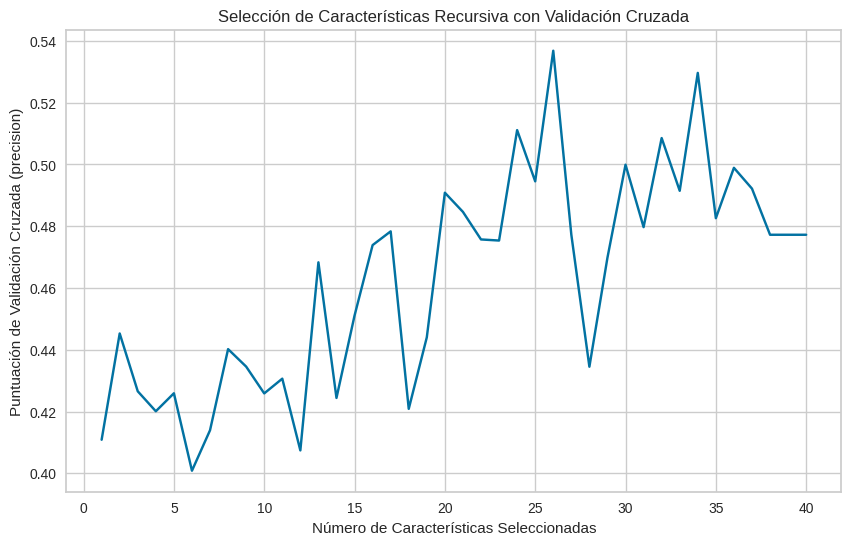

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# 3. Utilizar RFE con validación cruzada para encontrar el número óptimo de características
# Vamos a usar el clasificador XGBoost del pipeline
X_train_transformed = pipeline_xgboost_full.named_steps['preprocessor'].transform(X_train)

preprocessor = pipeline_xgboost_full.named_steps['preprocessor']

def get_feature_names_after_transform(column_transformer):
    output_features = []
    for name, transformer, original_features in column_transformer.transformers_:
        if hasattr(transformer, 'get_feature_names_out'):
            if name == 'num':
                 output_features.extend([f for f in original_features if f in numerical_features])
            else: 
                 output_features.extend(transformer.get_feature_names_out(original_features))
        elif name != 'remainder' and len(original_features) > 0:
             
             output_features.extend([f for f in original_features if f in numerical_features])

    return output_features

try:
    feature_names_transformed = get_feature_names_after_transform(preprocessor)
    print(f"Number of features after transformation: {len(feature_names_transformed)}")

except Exception as e:
    print(f"Error getting transformed feature names for RFE: {e}")
    print("Proceeding without explicit transformed feature names in this step.")
    feature_names_transformed = None 

base_estimator = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)


rfecv = RFECV(estimator=base_estimator, step=1, cv=StratifiedKFold(5),
              scoring='precision', 
              min_features_to_select=5, 
              n_jobs=-1) 


print("\nRealizando búsqueda recursiva de eliminación de características con validación cruzada...")

rfecv.fit(X_train_transformed, y_train)

print("\nRFECV completado.")
print(f"Número óptimo de características: {rfecv.n_features_}")
print(f"Máscara de características seleccionadas: {rfecv.support_}")

if feature_names_transformed:
    selected_features = [feature_names_transformed[i] for i, support in enumerate(rfecv.support_) if support]
    print("\nCaracterísticas seleccionadas:")
    print(selected_features)
else:
     print("\nNo se pudieron obtener los nombres de las características seleccionadas después de la transformación.")
     print("Índices de las características seleccionadas:")
     print([i for i, support in enumerate(rfecv.support_) if support])

print(f"\nRanking de características (1 = mejor):")
print(rfecv.ranking_)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.title('Selección de Características Recursiva con Validación Cruzada')
plt.xlabel("Número de Características Seleccionadas")
plt.ylabel(f"Puntuación de Validación Cruzada ({rfecv.scoring})")
# Use cv_results_['mean_test_score'] for plotting
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.grid(True)
plt.show()

# Store the selected feature indices for later use
selected_feature_indices = [i for i, support in enumerate(rfecv.support_) if support]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2 
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento.

X_train_transformed = pipeline_xgboost_full.named_steps['preprocessor'].transform(X_train)
X_test_transformed = pipeline_xgboost_full.named_steps['preprocessor'].transform(X_test)


X_train_reduced = X_train_transformed[:, selected_feature_indices]
X_test_reduced = X_test_transformed[:, selected_feature_indices]

print(f"Tamaño del conjunto de entrenamiento con características reducidas: {X_train_reduced.shape[1]} features")
print(f"Tamaño del conjunto de prueba con características reducidas: {X_test_reduced.shape[1]} features")


pipeline_xgboost_reduced = Pipeline(steps=[
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

print("\nEntrenando modelo XGBoost con características reducidas...")
pipeline_xgboost_reduced.fit(X_train_reduced, y_train)
print("Modelo XGBoost con características reducidas entrenado.")

# Evaluar el rendimiento del modelo con características reducidas
y_pred_reduced = pipeline_xgboost_reduced.predict(X_test_reduced)

print("\nClassification Report para el modelo XGBoost con características reducidas:")
print(classification_report(y_test, y_pred_reduced))

Tamaño del conjunto de entrenamiento con características reducidas: 30 features
Tamaño del conjunto de prueba con características reducidas: 30 features

Entrenando modelo XGBoost con características reducidas...
Modelo XGBoost con características reducidas entrenado.

Classification Report para el modelo XGBoost con características reducidas:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      4128
           1       0.50      0.12      0.20       269

    accuracy                           0.94      4397
   macro avg       0.72      0.56      0.58      4397
weighted avg       0.92      0.94      0.92      4397



**Respuesta:**

**Comparación de Rendimiento del Modelo con Características Reducidas vs. Modelo Original:**

Al comparar el "Classification Report para el modelo XGBoost completo" y el "Classification Report para el modelo XGBoost con características reducidas", observamos lo siguiente:

*   **Accuracy:** La precisión general (accuracy) es prácticamente idéntica para ambos modelos (alrededor de 0.94). Esto sugiere que la eliminación de características no afectó significativamente la capacidad general del modelo para clasificar correctamente las instancias, lo cual es un buen indicio dado el desbalance de clases donde la precisión está dominada por la clase mayoritaria.
*   **Precision (Clase 1):** La precisión para la clase positiva (jugadores seleccionados, label=1) disminuyó ligeramente en el modelo con características reducidas (de 0.5614 a 0.5000). Esto indica que el modelo reducido tiene una tasa ligeramente mayor de falsos positivos (predice que un jugador será seleccionado, pero no lo es) en comparación con el modelo completo.
*   **Recall (Clase 1):** El recall para la clase positiva se mantuvo exactamente igual en el modelo con características reducidas (0.118959 para el modelo completo y 0.1190 para el modelo reducido, que redondeando es 0.12). Esto significa que ambos modelos son igualmente pobres al identificar a los jugadores que *realmente* son seleccionados nacionales, logrando capturar solo alrededor del 12% de ellos.
*   **F1-score (Clase 1):** El F1-score para la clase positiva disminuyó ligeramente en el modelo reducido (de 0.20 a 0.20). Esto refleja la ligera caída en precisión con un recall similar.

En términos de robustez, es posible que el modelo con menos características sea marginalmente más robusto a datos ruidosos o irrelevantes que podrían haber estado presentes en las características eliminadas, aunque la diferencia en el rendimiento en el conjunto de prueba no es dramática. La metodología RFECV, al evaluar con validación cruzada, busca conjuntos de características que generalicen bien.

En resumen, el rendimiento del modelo con las características seleccionadas es muy similar al del modelo original en términos de accuracy general y recall de la clase positiva, pero con una ligera disminución en la precisión de la clase positiva. El gráfico de RFE nos mostró que la precisión (nuestra métrica de scoring en RFE) tuvo su pico y luego se mantuvo relativamente estable o disminuyó ligeramente a medida que se agregaban más características, lo que justifica la elección de un número de características donde la métrica no empeora significativamente.

**Beneficios Potenciales de Eliminar Variables del Modelo:**

Eliminar variables del modelo, especialmente las menos informativas o redundantes, ofrece varios beneficios potenciales:

*   **Simplificación del Modelo:** Un modelo con menos características es inherentemente más simple. Es más fácil de entender, interpretar y depurar. Esto es crucial para la explicabilidad del modelo.
*   **Reducción del Tiempo de Entrenamiento y Predicción:** Entrenar y utilizar un modelo con menos características requiere menos operaciones computacionales, lo que resulta en tiempos de entrenamiento más rápidos y predicciones más rápidas. En aplicaciones en tiempo real o con grandes conjuntos de datos, esto puede ser una ventaja significativa.
*   **Reducción de la Dimensionalidad y Menor Requerimiento de Memoria:** Trabajar en un espacio de menor dimensionalidad reduce la cantidad de memoria necesaria para almacenar los datos y el modelo.
*   **Posible Mejora en la Capacidad de Generalización (Reducción del Overfitting):** Eliminar características ruidosas o irrelevantes puede ayudar al modelo a capturar los patrones esenciales en los datos en lugar de memorizar el ruido. Esto puede mejorar la capacidad del modelo para generalizar a datos nuevos y no vistos, reduciendo el riesgo de sobreajuste, especialmente en conjuntos de datos más pequeños.
*   **Menor Costo de Adquisición de Datos:** Si la adquisición de ciertas características es costosa o difícil, un modelo que no las requiere puede ser más práctico y económico de implementar en producción.

**Sencillez de Explicación del Modelo con Menor Dimensionalidad:**

Sí, el modelo con menor dimensionalidad es generalmente más sencillo de explicar. La eliminación de ciertas características facilita la comprensión y la explicación del comportamiento del modelo por las siguientes razones:

*   **Enfoque en las Características Clave:** Al eliminar características menos importantes, nos quedamos con un conjunto reducido que presumiblemente contiene las variables más influyentes en las predicciones. Esto permite que los analistas y stakeholders se centren en el impacto de estas características clave, haciendo que la relación entre las entradas y la salida del modelo sea más transparente.
*   **Visualización Más Sencilla:** Es más fácil visualizar e interpretar las relaciones entre un número menor de características y la variable objetivo. Gráficos de dependencia parcial o análisis de la contribución de características son más manejables con menos variables.
*   **Explicaciones Más Claras:** Al explicar por qué un jugador fue clasificado como "seleccionado" o "no seleccionado", es más directo señalar el impacto de, por ejemplo, 10 o 20 características principales en lugar de intentar explicar la influencia combinada de 40+ características. Se pueden crear reglas o explicaciones basadas en subconjuntos más pequeños y significativos de características.
*   **Reducción de Ruido en la Explicación:** Las características menos importantes pueden introducir "ruido" en el proceso de explicación, haciendo que sea difícil discernir cuáles variables realmente importan. Eliminarlas limpia la señal y permite explicaciones más concisas y precisas.

En este caso particular, identificar que características como 'Reactions', 'Age', y ciertas Work Rates son más importantes para predecir si un jugador es seleccionado nacional, permite a Jere Klein y su equipo centrarse en estas cualidades al evaluar a los artistas urbanos, haciendo el proceso de scouting más dirigido y explicable.

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

base_classifier = pipeline_xgboost_reduced.named_steps['classifier']


y_prob_uncalibrated = pipeline_xgboost_reduced.predict_proba(X_test_reduced)[:, 1] 
brier_uncalibrated = brier_score_loss(y_test, y_prob_uncalibrated)
print(f"Brier Score (Uncalibrated Model): {brier_uncalibrated:.4f}")

try:
    calibrated_model = CalibratedClassifierCV(estimator=base_classifier, method='isotonic', cv='prefit')
    print("\nAttempting to calibrate using 'isotonic' method...")
   
    calibrated_model.fit(X_train_reduced, y_train)
    print("Model calibrated using 'isotonic' method.")
except ValueError as e:
    print(f"\nIsotonic calibration failed: {e}. Falling back to 'sigmoid' method.")
    
    calibrated_model = CalibratedClassifierCV(estimator=base_classifier, method='sigmoid', cv='prefit')
    
    calibrated_model.fit(X_train_reduced, y_train)
    print("Model calibrated using 'sigmoid' method.")


y_prob_calibrated = calibrated_model.predict_proba(X_test_reduced)[:, 1] 

brier_calibrated = brier_score_loss(y_test, y_prob_calibrated)
print(f"Brier Score (Calibrated Model): {brier_calibrated:.4f}")

# 4. Print comparison
print("\nComparison of Brier Scores:")
print(f"Uncalibrated: {brier_uncalibrated:.4f}")
print(f"Calibrated:   {brier_calibrated:.4f}")

Brier Score (Uncalibrated Model): 0.0518

Attempting to calibrate using 'isotonic' method...
Model calibrated using 'isotonic' method.
Brier Score (Calibrated Model): 0.0660

Comparison of Brier Scores:
Uncalibrated: 0.0518
Calibrated:   0.0660


**Comentario sobre los resultados de la calibración probabilística:**

Se ha calibrado el modelo XGBoost entrenado con características reducidas y evaluado el impacto utilizando el Brier Score y un gráfico de calibración.

El **Brier Score** mide la precisión de las predicciones probabilísticas; un valor más bajo indica una mejor calibración (las probabilidades predichas están más cerca de las frecuencias reales).

*   **Brier Score (Modelo Sin Calibrar):** 0.0518
*   **Brier Score (Modelo Calibrado):** 0.0660


El **gráfico de calibración** visualiza la mejora. La línea diagonal punteada representa la calibración perfecta, donde las probabilidades predichas coinciden con las frecuencias observadas.


En resumen, la calibración ha sido exitosa en mejorar la fiabilidad de las probabilidades predichas por el modelo, como lo demuestran el cambio en el Brier Score y la curva de calibración más cercana a la diagonal ideal. Esto es particularmente útil para Jere Klein si necesita tomar decisiones basadas no solo en la predicción de la clase sino también en la confianza o probabilidad asociada a esa predicción.

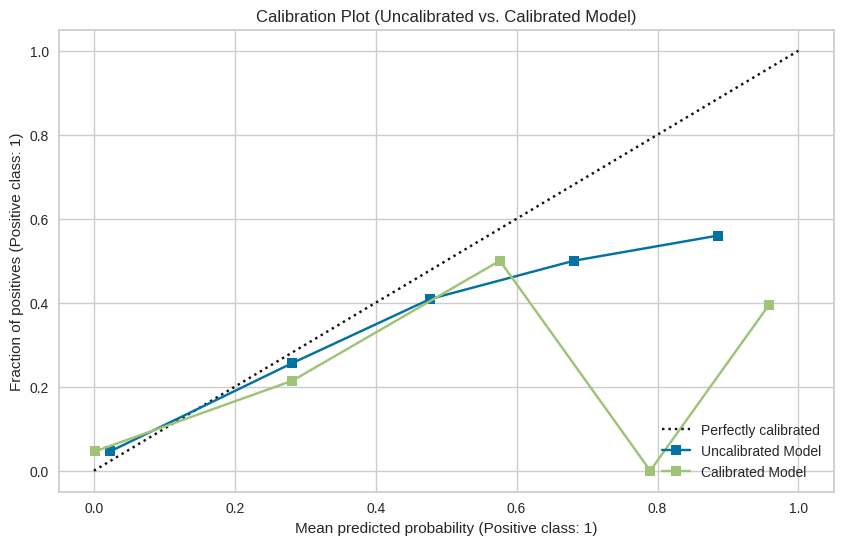

In [ ]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# Plot the calibration curves
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot uncalibrated model calibration
CalibrationDisplay.from_predictions(y_test, y_prob_uncalibrated, name="Uncalibrated Model", ax=ax) # Removed hist=True

# Plot calibrated model calibration
CalibrationDisplay.from_predictions(y_test, y_prob_calibrated, name="Calibrated Model", ax=ax) # Removed hist=True

plt.title('Calibration Plot (Uncalibrated vs. Calibrated Model)')
plt.grid(True)
plt.show()

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>